In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from tqdm import tqdm

In [8]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
ifg_color = '#6A5ACD'
insula_color = '#D4AF37'


reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')

'notebook'

# Load TRF results

In [43]:
ref = 'bipolar'

tasks = ['PhonemeSequence',
         'LexicalDelay']


pts = []
for task in tasks:
    
    print(task)
    hga_path = BIDSPath(
        root=f'../results/{task}({ref})',
        datatype='mtrf',
        suffix='e',
        extension='.csv',
        check=False,
    )
    pts.extend(hga_path.match())

HGAs = pd.concat([pd.read_csv(path) for path in pts], ignore_index=True)
HGAs.head()

PhonemeSequence
LexicalDelay


,channel,time,weight,pearsonr,feature,subject,task,description,processing,significant,label,roi,hemi,x,y,z,suffix
0,D0019_ROG13-14,-0.203125,-2.779224,-0.002101,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,False,ctx_rh_G_occipital_middle,mOccG,R,41.472074,-88.150203,-3.545099,e
1,D0019_ROG13-14,-0.195312,-0.226842,-0.002101,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,False,ctx_rh_G_occipital_middle,mOccG,R,41.472074,-88.150203,-3.545099,e
2,D0019_ROG13-14,-0.187500,1.036661,-0.002101,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,False,ctx_rh_G_occipital_middle,mOccG,R,41.472074,-88.150203,-3.545099,e
3,D0019_ROG13-14,-0.179688,1.261365,-0.002101,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,False,ctx_rh_G_occipital_middle,mOccG,R,41.472074,-88.150203,-3.545099,e
4,D0019_ROG13-14,-0.171875,0.831937,-0.002101,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,False,ctx_rh_G_occipital_middle,mOccG,R,41.472074,-88.150203,-3.545099,e


In [56]:
coefs = HGAs.groupby('channel').agg({
    'pearsonr': 'mean',  
    'significant': 'any',
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

# coefs = coefs[(coefs.significant==True)]
coefs.head()

,channel,pearsonr,significant,x,y,z,roi,hemi,subject,description,task
0,D0019_RIIH5-6,-0.017116,False,11.886836,-94.046488,10.403848,OPC,R,D0019,Repeat,PhonemeSequence
1,D0019_RLSO7-8,0.020172,False,18.457267,-10.274114,-31.949923,PhG,R,D0019,Repeat,PhonemeSequence
2,D0019_ROG12-13,-0.003233,False,31.749467,-83.233475,16.079752,OccS,R,D0019,Repeat,PhonemeSequence
3,D0019_ROG13-14,-0.002101,False,41.472074,-88.150203,-3.545099,mOccG,R,D0019,Repeat,PhonemeSequence
4,D0019_ROG18-19,-0.030226,False,41.531682,-78.171196,19.605156,Intersection,R,D0019,Repeat,PhonemeSequence


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-02 13:53:54.519 (11913.115s) [    7F2E532C1440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x3561cb60): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-02 13:53:54.603 (11913.199s) [    7F2E532C1440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x3561cb60): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning

左半球: 显著 137 个电极
右半球: 显著 62 个电极


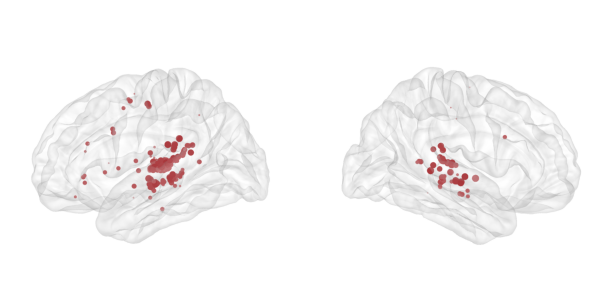

In [ ]:
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

sig_coefs = coefs[coefs.significant == True].copy()

cord = sig_coefs[['x', 'y', 'z']].values
coef_values = sig_coefs['pearsonr'].values
hemis = sig_coefs['hemi'].values

mask_lh = hemis == 'L'
mask_rh = hemis == 'R'

cmap = reds
if len(coef_values) > 0:
    vlim = np.nanpercentile(np.abs(coef_values), 98)
    if not np.isfinite(vlim) or vlim == 0:
        mx = np.nanmax(np.abs(coef_values))
        vlim = float(mx) if np.isfinite(mx) and mx != 0 else 1.0
    norm = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)
else:
    vlim = 1.0
    norm = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)

size_min, size_max = 5, 35

def coef_to_size(c, vlim, size_min, size_max):
    if vlim == 0:
        return size_min
    normalized = np.clip(np.abs(c) / vlim, 0, 1)
    return size_min + normalized * (size_max - size_min)

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)


def add_electrodes(
    brain, 
    coords_on_pial, 
    coef_vals, 
    cmap, 
    norm, 
    vlim, 
    size_min, 
    size_max
):
    for i in range(len(coords_on_pial)):
        pt = coords_on_pial[i:i+1]
        c = coef_vals[i]
        color = cmap(norm(c))[:3]
        size = coef_to_size(c, vlim, size_min, size_max)
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            line_width=3,  # 添加黑色边框
            render_lines_as_tubes=False,
            smooth_shading=False,
            opacity=1,
        )


if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_coef = coef_values[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_on_pial = lh_coords_pial[lh_indices]
    add_electrodes(lh_brain, lh_cord_on_pial, lh_coef, cmap, norm, vlim, size_min, size_max)

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_coef = coef_values[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_on_pial = rh_coords_pial[rh_indices]
    add_electrodes(rh_brain, rh_cord_on_pial, rh_coef, cmap, norm, vlim, size_min, size_max)

print(f"左半球: 显著 {int(mask_lh.sum())} 个电极")
print(f"右半球: 显著 {int(mask_rh.sum())} 个电极")

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.show()

VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-02 13:33:46.011 (10704.607s) [    7F2E532C1440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2985ed00): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-02 13:33:46.089 (10704.686s) [    7F2E532C1440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2985ed00): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning

左半球: 显著 137 个电极
右半球: 显著 62 个电极


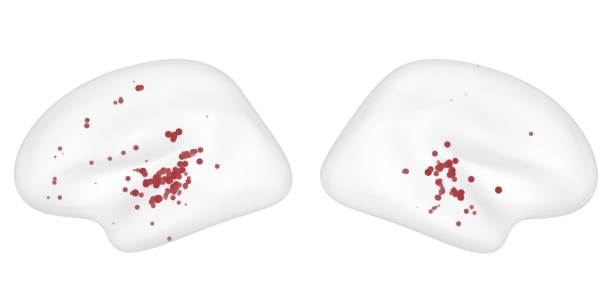

In [55]:
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

sig_coefs = coefs[coefs.significant == True].copy()

cord = sig_coefs[['x', 'y', 'z']].values
coef_values = sig_coefs['pearsonr'].values
hemis = sig_coefs['hemi'].values

mask_lh = hemis == 'L'
mask_rh = hemis == 'R'

cmap = reds
if len(coef_values) > 0:
    vlim = np.nanpercentile(np.abs(coef_values), 98)
    if not np.isfinite(vlim) or vlim == 0:
        mx = np.nanmax(np.abs(coef_values))
        vlim = float(mx) if np.isfinite(mx) and mx != 0 else 1.0
    norm = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)
else:
    vlim = 1.0
    norm = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)

size_min, size_max = 5, 35

def coef_to_size(c, vlim, size_min, size_max):
    if vlim == 0:
        return size_min
    normalized = np.clip(np.abs(c) / vlim, 0, 1)
    return size_min + normalized * (size_max - size_min)

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_infl_path = f"{recon_dir}/fsaverage/surf/rh.inflated"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_coords_infl, _ = mne.read_surface(rh_infl_path)
rh_tree = cKDTree(rh_coords_pial)


def add_electrodes(brain, coords_on_infl, coef_vals, cmap, norm, vlim, size_min, size_max):
    for i in range(len(coords_on_infl)):
        pt = coords_on_infl[i:i+1]
        c = coef_vals[i]
        color = cmap(norm(c))[:3]
        size = coef_to_size(c, vlim, size_min, size_max)
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1,
        )


if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_coef = coef_values[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_on_infl = lh_coords_infl[lh_indices]
    add_electrodes(lh_brain, lh_cord_on_infl, lh_coef, cmap, norm, vlim, size_min, size_max)

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_coef = coef_values[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_on_infl = rh_coords_infl[rh_indices]
    add_electrodes(rh_brain, rh_cord_on_infl, rh_coef, cmap, norm, vlim, size_min, size_max)

print(f"左半球: 显著 {int(mask_lh.sum())} 个电极")
print(f"右半球: 显著 {int(mask_rh.sum())} 个电极")

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.show()